In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from sklearn.datasets import load_wine
from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import random

import math

from tensorflow.keras.callbacks import EarlyStopping

import itertools

In [2]:
iris_data = load_iris(as_frame = True)
iris_data = iris_data.frame
print(iris_data.head)

print("")

wine_data = load_wine(as_frame = True)
wine_data = wine_data.frame
print(wine_data.head)

print("")

digits_data = load_digits(as_frame = True)
digits_data = digits_data.frame
print(digits_data.head)

print("")


<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

In [3]:
print(iris_data.dtypes)
print ("")
print(wine_data.dtypes)
print("")
print(digits_data.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

pixel_0_0    float64
pixel_0_1    float64
pixel_0_2    float64
pixel_0_3    float64
pixel_0_4    float64
              ...   
pixel_7_4    float64
pixel_7_5    float64
pixel_7_6    float64
pixel_7_7    float64
target         int64
Length: 65, dtype: object


# Iris data preprocessing

In [4]:
iris_data_X = iris_data.iloc[:, 0:4]
iris_data_y = iris_data.iloc[:, 4]

seed = 42

X_iris_train, X_iris_tmp, y_iris_train, y_iris_tmp = train_test_split(
        iris_data_X, iris_data_y, test_size = 0.4, stratify = iris_data_y, random_state = seed
    )

X_iris_val, X_iris_test, y_iris_val, y_iris_test = train_test_split(
        X_iris_tmp, y_iris_tmp, test_size = 0.5, stratify = y_iris_tmp, random_state=seed
    )

scaler = StandardScaler().fit(X_iris_train)
X_iris_train = scaler.transform(X_iris_train)
X_iris_val = scaler.transform(X_iris_val)
X_iris_test = scaler.transform(X_iris_test)

OHE = np.eye(3, dtype=np.float64)
y_iris_train, y_iris_val, y_iris_test = OHE[y_iris_train], OHE[y_iris_val], OHE[y_iris_test]

print(X_iris_train.shape)
print(y_iris_train.shape)

(90, 4)
(90, 3)


# Wine data preprocessing

In [5]:
wine_data_X = wine_data.iloc[:, 0:13]
wine_data_y = wine_data.iloc[:, 13]

seed = 42

X_wine_train, X_wine_tmp, y_wine_train, y_wine_tmp = train_test_split(
        wine_data_X, wine_data_y, test_size = 0.4, stratify = wine_data_y, random_state = seed
    )

X_wine_val, X_wine_test, y_wine_val, y_wine_test = train_test_split(
        X_wine_tmp, y_wine_tmp, test_size = 0.5, stratify = y_wine_tmp, random_state=seed
    )

scaler = StandardScaler().fit(X_wine_train)
X_wine_train = scaler.transform(X_wine_train)
X_wine_val = scaler.transform(X_wine_val)
X_wine_test = scaler.transform(X_wine_test)

OHE = np.eye(3, dtype=np.float64)
y_wine_train, y_wine_val, y_wine_test = OHE[y_wine_train], OHE[y_wine_val], OHE[y_wine_test]

# Digits data preprocessing

In [6]:
digits_data_X = digits_data.iloc[:, 0:64]
digits_data_y = digits_data.iloc[:, 64]         

seed = 42

X_digits_train, X_digits_tmp, y_digits_train, y_digits_tmp = train_test_split(
        digits_data_X, digits_data_y, test_size = 0.4, stratify = digits_data_y, random_state = seed
    )

X_digits_val, X_digits_test, y_digits_val, y_digits_test = train_test_split(
        X_digits_tmp, y_digits_tmp, test_size = 0.5, stratify = y_digits_tmp, random_state = seed
    )

X_digits_train = X_digits_train.to_numpy(dtype=np.float64) / 16.0
X_digits_val   = X_digits_val.to_numpy(dtype=np.float64) / 16.0
X_digits_test  = X_digits_test.to_numpy(dtype=np.float64) / 16.0

OHE = np.eye(10, dtype=np.float64)
y_digits_train, y_digits_val, y_digits_test = (OHE[y.to_numpy().astype(int)]
    for y in (y_digits_train, y_digits_val, y_digits_test))

# Initialisation of function approximation methods

In [7]:
seed = 42
std = 0.1

rng = np.random.default_rng(seed)

n_low_comp = 2000
n_med_comp = 2000
n_hig_comp = 2000

x1_LC = rng.uniform(-2, 2, n_low_comp)
x2_LC = rng.uniform(-2, 2, n_low_comp)
LC_eq = np.exp(-(x1_LC**2 + x2_LC**2))
LC_noise = std * LC_eq.std()
data_LC = pd.DataFrame({"x1": x1_LC, "x2": x2_LC,"y": LC_eq + rng.normal(0, LC_noise, n_low_comp)})

x_MC = rng.uniform(-1, 1, n_med_comp)
MC_eq = np.sin(6 * x_MC) * np.exp(-x_MC**2) + 0.3 * np.cos(24 * x_MC)
MC_noise = std * MC_eq.std()
data_MC = pd.DataFrame({"x": x_MC, "y": MC_eq + rng.normal(0, MC_noise, n_med_comp)})

x1_HC = rng.uniform(-1, 1, n_hig_comp)
x2_HC = rng.uniform(-1, 1, n_hig_comp)
HC_eq = (1 - x1_HC)**2 + 100 * (x2_HC - x1_HC**2)**2
HC_noise = std * HC_eq.std()
data_HC = pd.DataFrame({"x1": x1_HC, "x2": x2_HC,"y": HC_eq + rng.normal(0, HC_noise, n_hig_comp)})

#ok now we have the data and i think it is correct, now lets just print and see how it looks

print(data_LC.shape, data_MC.shape, data_HC.shape) #looks fine, just dont know about the features. check that later, just want a baseline for now to work with
print("")
print(data_LC.head())
print("")
print(data_MC.head())
print("")
print(data_HC.head())


(2000, 3) (2000, 2) (2000, 3)

         x1        x2         y
0  1.095824  1.370928  0.019820
1 -0.244486 -0.214442  0.862065
2  1.434392  1.811901  0.038753
3  0.789472  0.603178  0.433480
4 -1.623291 -1.536405 -0.005177

          x         y
0  0.090069  0.343999
1  0.698131 -0.695708
2 -0.549515  0.418765
3 -0.944672 -0.061458
4 -0.923549 -0.068758

         x1        x2           y
0  0.334250  0.000551  -22.507490
1 -0.793220 -0.523927  138.923763
2 -0.700086 -0.414460   86.036577
3  0.267965 -0.215826    8.592144
4  0.737412 -0.008958   34.413991


# Low complexity preprocessing

In [8]:
data_LC_x = data_LC.iloc[:, 0:2]
data_LC_y = data_LC.iloc[:, [2]]

seed = 42

X_LC_train, X_LC_tmp, y_LC_train, y_LC_tmp = train_test_split(
        data_LC_x, data_LC_y, test_size = 0.4, random_state = seed
    )

X_LC_val, X_LC_test, y_LC_val, y_LC_test = train_test_split(
        X_LC_tmp, y_LC_tmp, test_size = 0.5, random_state = seed
    )

X_LC_scaler = StandardScaler().fit(X_LC_train)
X_LC_train = X_LC_scaler.transform(X_LC_train)
X_LC_val = X_LC_scaler.transform(X_LC_val)
X_LC_test = X_LC_scaler.transform(X_LC_test)

y_LC_scaler = StandardScaler().fit(y_LC_train.to_numpy().reshape(-1, 1))
y_LC_train = y_LC_scaler.transform(y_LC_train.to_numpy().reshape(-1, 1))
y_LC_val = y_LC_scaler.transform(y_LC_val.to_numpy().reshape(-1, 1))
y_LC_test = y_LC_scaler.transform(y_LC_test.to_numpy().reshape(-1, 1))

# Medium complexity preprocessing

In [9]:
data_MC_x = data_MC.iloc[:, 0:1]
data_MC_y = data_MC.iloc[:, [1]]

seed = 42

X_MC_train, X_MC_tmp, y_MC_train, y_MC_tmp = train_test_split(
        data_MC_x, data_MC_y, test_size = 0.4, random_state = seed
    )

X_MC_val, X_MC_test, y_MC_val, y_MC_test = train_test_split(
        X_MC_tmp, y_MC_tmp, test_size = 0.5, random_state = seed
    )

X_MC_scaler = StandardScaler().fit(X_MC_train)
X_MC_train = X_MC_scaler.transform(X_MC_train)
X_MC_val = X_MC_scaler.transform(X_MC_val)
X_MC_test = X_MC_scaler.transform(X_MC_test)

y_MC_scaler = StandardScaler().fit(y_MC_train.to_numpy().reshape(-1, 1))
y_MC_train = y_MC_scaler.transform(y_MC_train.to_numpy().reshape(-1, 1))
y_MC_val = y_MC_scaler.transform(y_MC_val.to_numpy().reshape(-1, 1))
y_MC_test = y_MC_scaler.transform(y_MC_test.to_numpy().reshape(-1, 1))

# High Complexity preprocessing

In [10]:
data_HC_x = data_HC.iloc[:, 0:2]
data_HC_y = data_HC.iloc[:, [2]]

seed = 42

X_HC_train, X_HC_tmp, y_HC_train, y_HC_tmp = train_test_split(
        data_HC_x, data_HC_y, test_size = 0.4, random_state = seed
    )

X_HC_val, X_HC_test, y_HC_val, y_HC_test = train_test_split(
        X_HC_tmp, y_HC_tmp, test_size = 0.5, random_state = seed
    )

X_HC_scaler = StandardScaler().fit(X_HC_train)
X_HC_train = X_HC_scaler.transform(X_HC_train)
X_HC_val = X_HC_scaler.transform(X_HC_val)
X_HC_test = X_HC_scaler.transform(X_HC_test)

y_HC_scaler = StandardScaler().fit(y_HC_train.to_numpy().reshape(-1, 1))
y_HC_train = y_HC_scaler.transform(y_HC_train.to_numpy().reshape(-1, 1))
y_HC_val = y_HC_scaler.transform(y_HC_val.to_numpy().reshape(-1, 1))
y_HC_test = y_HC_scaler.transform(y_HC_test.to_numpy().reshape(-1, 1))

### Note: when it comes to the classifcation problems we will use a categorical cross-entropy function and then for the function appoxiamtion methods, we will use the MSE
### Note: when it comes to the selection of the activation function, based on the paper that has been read, the 4 that can be considered is: Tanh, ReLU, APL, Swish. With some good defending, it can be seen that tanh will be the best AF for our 6 models. 


### Mabye consider a dataset that by chance has output skewness

# Calculations for the Iris datasets

#### For the number of hidden units, it will be around the linear sum of the input features and output classes, so covering a wide range will ensure that the optimal hidden units are found


In [11]:
#Iris_NN = []

#for h in range(1, 8):
#    for run in range(5):
#        random.seed(42)
#        stopping = EarlyStopping( monitor = "val_loss", patience=20, restore_best_weights=True)
#        
#        model = Sequential()
#         model.add(layers.Input(shape = (4,)))
#        model.add(layers.Dense(h, activation = "tanh"))
#        model.add(layers.Dense(3, activation = "softmax")) #keep in mind this might change once we select a harder model, 3 represents the number of classes
#        model.compile(loss = "categorical_crossentropy", metrics = ["Accuracy"])
#
#        model.fit(X_iris_train, y_iris_train, validation_data = (X_iris_val, y_iris_val), epochs = 500, batch_size = len(X_iris_train), callbacks = stopping, verbose=0)
#        cross_ent_vals, acc_vals = model.evaluate(X_iris_val, y_iris_val)
#
#        Iris_NN.append({"hidden units": h, "run": run, "Cross entropy value": cross_ent_vals, "accuracy value": acc_vals})
#
#final_Iris_SGD_results = pd.DataFrame(Iris_NN)        
#print(final_Iris_SGD_results)

#### This above does not really look that correct by using the keras library. Other technique might to be to try in in numpy

In [12]:
#h_range = range(1, 26)
#n_repeat = 100
#Iris_SGD_results = []

#N_i = X_iris_train.shape[1]
#N_o = y_iris_train.shape[1]

#for h in h_range:
#    for run in range(n_repeat):
#        rng = np.random.default_rng([seed, h, run])
        
#        LB = (1/np.sqrt(N_i))
#        UB = 1/np.sqrt(h)
#        Weight_1 = rng.uniform(-LB, LB, (N_i, h)).ravel()
#        Weight_2 = rng.uniform(-UB, -UB, (h, N_o)).ravel()
        
#        biases_h = np.zeros(h)
#        biases_o = np.zeros(N_o)

#        H = np.tanh(X_iris_val @ Weight_1 + biases_h)
#        Z = H @ Weight_2 + biases_o
#        Z = Z - Z.max(axis = 1, keepdims = True)
#        E = np.exp(Z)
#        P = E / E.sum(axis = 1, keepdims = True)
        
#       Cross_Ent_Iris = -np.mean(np.sum(y_iris_val * np.log(P + 1e-12), axis=1))
## this fuction might not work on its one since i need function for a lot of the calls, mabye come back to this later to see of we can 
## can work this out somehow,

#### ok so what i am going to try now is the use of functions, where i first get the functions to initialise the weights, feedForward, backpropagation for the classification settings, the regression problems should be the same except for the forward function except mabye for the return functions.

### Note for evaluaters: the comments in the code is just for me so make sure that my logic is correct except mabye take note of the one line in the forward_classi where i did state something of possible interest.

In [13]:
def init_weights(N_in, N_out, h, rng):
        LB = 1.0 / np.sqrt(N_in)
        UB = 1.0 / np.sqrt(h)
    
        W1 = rng.uniform(-LB, LB, (N_in, h)) # This will create a matrix of weigts N_in * h
        b1 = rng.uniform(-LB, LB, h)
    
        W2 = rng.uniform(-UB, UB, (h, N_out)) #This will creates a matirx of weights h * N_out 
        b2 = rng.uniform(-UB, UB, N_out)
    
        return (W1, b1, W2, b2)

def forward_classi(params, X):
        W1, b1, W2, b2 = params
        # Firstly we have to calculate the product units in the hidden layer, namely hid_prod
        hid_prod = np.tanh(X @ W1 + b1) # we select tanh, since for a good reason, note to mention in report why this activation function was chosen 
    
        # Then once we have the hidden products layer we have calculate the product units of the output layer, namely out_prod
        out_prod = hid_prod @ W2 + b2
        out_prod = out_prod - out_prod.max(axis=1, keepdims=True) # Some of my data is large, so it caused numerical overflow, so I did use the help of the internet https://stackoverflow.com/questions/42599498/numerically-stable-softmax 

        #Then afterwords we calculate the activation function for the output layer using the softmax function
        E = np.exp(out_prod) 
        soft_max = E / E.sum(axis=1, keepdims=True)
    
        return hid_prod, soft_max            

def grad_classi(params, X, Y):
        W1, b1, W2, b2 = params
        hid_prod, out_prod = forward_classi(params, X)
    
        n = X.shape[0]

        #Next we have to get the error signals of the output layer and hidden layer, where we calculations of error signals was derived from a mathematical equation
        d_out = (out_prod - Y) / n                                         
        d_hid = (d_out @ W2.T) * (1.0 - hid_prod ** 2)  # Note that I got the (1 - hid_prod^2) from the derivative of tanh

        # use slides 146 in your report, mabye
        dW1 = X.T @ d_hid
        db1 = d_hid.sum(axis=0)
    
        dW2 = hid_prod.T @ d_out
        db2 = d_out.sum(axis=0)
    
        return (dW1, db1, dW2, db2)

def forward_regression(params, X):
        W1, b1, W2, b2 = params
        # Firstly we have to calculate the product units in the hidden layer, namely hid_prod
        hid_prod = np.tanh(X @ W1 + b1) # we select tanh, since for a good reason, note to mention in report why this activation function was chosen 
    
        # Then once we have the hidden products layer we have calculate the product units of the output layer, namely out_prod
        out_prod = hid_prod @ W2 + b2
           
        return hid_prod, out_prod            

def grad_regression(params, X, Y):
        W1, b1, W2, b2 = params
        hid_prod, out_prod = forward_regression(params, X)
    
        n = X.shape[0]

        #Next we have to get the error signals of the output layer and hidden layer, where we calculations of error signals was derived from a mathematical equation
        d_out = (out_prod - Y) / n                                         
        d_hid = (d_out @ W2.T) * (1.0 - hid_prod ** 2)  # Note that I got the (1 - hid_prod^2) from the derivative of tanh

        # use slides 146 in your report, mabye
        delta_W1 = X.T @ d_hid
        delta_b1 = d_hid.sum(axis=0)
    
        delta_W2 = hid_prod.T @ d_out
        delta_b2 = d_out.sum(axis=0)
    
        return (delta_W1, delta_b1, delta_W2, delta_b2)

In [14]:
N_i = X_iris_train.shape[1]
N_o = y_iris_train.shape[1]
n = X_iris_train.shape[0]

patience = 30 # 30 20% of totoal epochs
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1 #tolerance
h_vals = range(5, 26) # 1, 16

h_vals_row = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows = []

In [41]:
def train_sgd(X_tr, Y_tr, X_va, Y_va, w0, n, a, h, batch_size=32):
    rng_shuffle = np.random.default_rng(seed)
    W1, bias1, W2, bias2 = w0
    V1, V_bias1, V2, V_bias2 = np.zeros_like(W1), np.zeros_like(bias1), np.zeros_like(W2), np.zeros_like(bias2)

    worst_err = 100000
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0

    for epoch in range(1, epochs + 1):
        idx = rng_shuffle.permutation(X_tr.shape[0])
        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]

            g1, g_bias1, g2, g_bias2 = grad_classi((W1, bias1, W2, bias2), X_tr[batch_idx], Y_tr[batch_idx])

            V1 = -n * g1 + a * V1
            V_bias1 = -n * g_bias1 + a * V_bias1
            V2 = -n * g2 + a * V2
            V_bias2 = -n * g_bias2 + a * V_bias2

            W1 += V1; bias1 += V_bias1; W2 += V2; bias2 += V_bias2

        val_err = -np.mean(np.sum(Y_va * np.log(forward_classi((W1, bias1, W2, bias2), X_va)[1] + 1e-12), axis=1))
        if val_err < worst_err:
            worst_err, best_w, pat_threshold = val_err, (W1, bias1, W2, bias2), 0
        else:
            pat_threshold += 1
        if pat_threshold >= patience:
            break
    return best_w, worst_err

In [16]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd(X_iris_train, y_iris_train, X_iris_val, y_iris_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])
            #take all 10 performances and then put it into a dataframe and then calculate the mean error of all 10 and store that into 
            #a other dataframe, which will be evaluated once all iterations has been run
            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()}) 
            h_vals_df = pd.DataFrame(h_vals_row, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

#take the iteration combination that has the lowest error and store those values as the best 
best_h_err_index = h_vals_df['val_err_mean'].idxmin()
print(h_vals_df.loc[best_h_err_index])

best_err = h_vals_df.loc[best_h_err_index].iloc[3]
best_alpha = h_vals_df.loc[best_h_err_index].iloc[2]
best_n_parameter = h_vals_df.loc[best_h_err_index].iloc[1]
best_h = h_vals_df.loc[best_h_err_index].iloc[0]
print(best_err, best_alpha, best_n_parameter, best_h)

h               13.000000
n_parameter      0.100000
alpha            0.800000
val_err_mean     0.021008
Name: 258, dtype: float64
0.021008017620243014 0.8 0.1 13.0


In [17]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h), rng) 
    final_weights, final_best_err = train_sgd(X_iris_train, y_iris_train, X_iris_val, y_iris_val, Final_Initial_weights, best_n_parameter, best_alpha, best_h)

    Final_hid, Final_out = forward_classi(final_weights, X_iris_test)
    true, pred = y_iris_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o)) 
    np.add.at(C, (true, pred), 1)                # rows = true class, columns = predicted class
    confusion += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows.append({"val_err": final_best_err,
                           "accuracy": tp.sum() / C.sum(), "test_cross_entropy": -np.mean(np.sum(y_iris_test * np.log(Final_out), axis=1)),
                           "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final = pd.DataFrame(final_model_rows)
final = final.agg(["mean", "std"]).T
print(final.round(5).to_string())


                       mean      std
val_err             0.02657  0.01785
accuracy            0.94778  0.01680
test_cross_entropy  0.16663  0.09932
precision           0.95539  0.01273
recall              0.94778  0.01680
f1                  0.94736  0.01710


# OK now lets do the same for the SCG

In [18]:
def train_scg(X_tr, Y_tr, X_va, Y_va, w0, sigma, lambda1, h):
    
    ################################################## All of this is just step one where we set the inital variables up(step 1)
    
    W1, bias1, W2, bias2 = w0
    total_params = W1.size + bias1.size + W2.size + bias2.size
    
    lam_bar = 0.0 #step 1 from notes

    hid_prod, out_prod = forward_classi((W1, bias1, W2, bias2), X_tr)
    E = -np.mean(np.sum(Y_tr * np.log(out_prod + + 1e-12), axis=1)) 

    g1, g_bias1, g2, g_bias2 = grad_classi((W1, bias1, W2, bias2), X_tr, Y_tr)
    r1, r_bias1, r2, r_bias2 = -g1, -g_bias1, -g2, -g_bias2   
    p1, p_bias1, p2, p_bias2 = r1, r_bias1, r2, r_bias2
    
    success = True
    delta_k = 0.0

    worst_err = 100000
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0
    ###################################################

    # now for every iteration, same as the epoch start
    for k in range(1, max_iter + 1):

        # Firstly, we check that the gradient is not 0, since then this is the minimum we want(Step 9 is first due to the initial grads)
        grad_r_total = np.sqrt(np.sum(r1 * r1) + np.sum(r_bias1 * r_bias1) + np.sum(r2 * r2) + np.sum(r_bias2 * r_bias2))
        
        if grad_r_total < grad_tol:
            break
        #same with 
        
        grad_p_total_k = np.sum(p1 * p1) + np.sum(p_bias1 * p_bias1) + np.sum(p2 * p2) + np.sum(p_bias2 * p_bias2) #this is the |Pk|^2 that gets used 

#####################################################################################(step 2)
        
        if success:                                                  
            sigma_k = sigma / np.sqrt(grad_p_total_k) #SIGMA_k = sigma/|p_k|
            
            W1_new = W1 + (sigma_k * p1)
            bias1_new = bias1 + (sigma_k * p_bias1)
            W2_new = W2 + (sigma_k * p2)
            bias2_new = bias2 + (sigma_k * p_bias2)

            Next_W1, Next_bias1, Next_W2, Next_bias2 = grad_classi((W1_new, bias1_new, W2_new, bias2_new), X_tr, Y_tr)
            
            g1_suc, bias1_suc, g2_suc, bias2_suc = grad_classi((W1, bias1, W2, bias2), X_tr, Y_tr)
            
            s1 = (Next_W1 - g1_suc)/ sigma_k
            s_bias1 = (Next_bias1 - bias1_suc)/ sigma_k
            s2 = (Next_W2 - g2_suc)/ sigma_k
            s_bias2 = (Next_bias2 - bias2_suc)/ sigma_k  

            delta_k = np.sum(p1 * s1) + np.sum(p_bias1 * s_bias1) + np.sum(p2 * s2) + np.sum(p_bias2 * s_bias2)
            
##############################################################################################(step 3)
        
        delta_k = delta_k + (lambda1 - lam_bar) * grad_p_total_k                         
        
##############################################################################################(step 4)
        
        if delta_k <= 0:                                                
            lam_bar = 2.0 * (lambda1 - delta_k / grad_p_total_k)
            delta_k = -delta_k + lambda1 * grad_p_total_k
            lambda1 = lam_bar
            
##############################################################################################(Step 5)
        mu = np.sum(p1 * r1) + np.sum(p_bias1 * r_bias1) + np.sum(p2 * r2) + np.sum(p_bias2 * r_bias2)
        alpha_k = mu / delta_k
###############################################################################################(Step 6)
        
        W1_delta = W1 + alpha_k * p1
        bias1_delta = bias1 + alpha_k * p_bias1
        W2_delta = W2 + alpha_k * p2
        bias2_delta = bias2 + alpha_k * p_bias2

        hid_prod_delta, out_prod_delta = forward_classi((W1_delta, bias1_delta, W2_delta, bias2_delta), X_tr)
        
        E_new = -np.mean(np.sum(Y_tr * np.log(out_prod_delta + 1e-12), axis=1))   

        Delta = 2.0 * delta_k * (E - E_new) / mu ** 2                   
        
#################################################################################################(Step 7)
        
        if Delta >= 0:                                                

            W1 = W1 + alpha_k * p1
            bias1 = bias1 + alpha_k * p_bias1
            W2 = W2 + alpha_k * p2
            bias2 = bias2 + alpha_k * p_bias2
            
            r1_temp, r_bias1_temp, r2_temp, r_bias2_temp = r1, r_bias1, r2, r_bias2
            E = E_new
            
            g1_temp, g_bias1_temp, g2_temp, g_bias2_temp = grad_classi((W1, bias1, W2, bias2), X_tr, Y_tr) 
            r1, r_bias1, r2, r_bias2 = -g1_temp, -g_bias1_temp, -g2_temp, -g_bias2_temp
            
            lam_bar = 0.0 
            success = True

            if k % total_params == 0:                                   
                p1 = r1
                p_bias1 = r_bias1
                p2 = r2
                p_bias2 = r_bias2
            else:
                new_grad_total = np.sum(r1 * r1) + np.sum(r_bias1 * r_bias1) + np.sum(r2 * r2) + np.sum(r_bias2 * r_bias2)
                r_multi = np.sum(r1 * r1_temp) + np.sum(r_bias1 * r_bias1_temp) + np.sum(r2 * r2_temp) + np.sum(r_bias2 * r_bias2_temp)
                beta_k = (new_grad_total - r_multi) / mu
                
                p1 = r1 + beta_k * p1
                p_bias1 = r_bias1 + beta_k * p_bias1
                p2 = r2 + beta_k * p2
                p_bias2 = r_bias2 + beta_k * p_bias2

            if Delta >= 0.75:
                lambda1 = 0.25 * lambda1                                      
        else:
            lam_bar = lambda1
            success = False                             
            
#####################################################################################################(step 8)
        
        if Delta < 0.25:                        
            lambda1 = lambda1 + delta_k * (1.0 - Delta) / grad_p_total_k
            
######################################################################################################
        hid_prod_va, out_prod_va = forward_classi((W1, bias1, W2, bias2), X_va)
        val_err = -np.mean(np.sum(Y_va * np.log(out_prod_va + + 1e-12), axis=1))   

        if val_err < worst_err:
            worst_err = val_err
            best_w = (W1, bias1, W2, bias2)
            pat_threshold = 0
        else:
            pat_threshold += 1

        if pat_threshold >= patience:
            break

    return best_w, worst_err

#### Below should be all the same except for the new metrics that we run over.

In [19]:
N_i = X_iris_train.shape[1]
N_o = y_iris_train.shape[1]
n = X_iris_train.shape[0]
       

#In step one it states that the parameter values must be between the 2 values 0 and 1e-4 
sigma_vals  = [1e-7, 1e-6, 1e-5, 1e-4]   
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]     
grad_tol = 1e-6 # note that the gradient won't ever be 0, so we set it to a small value first.         

## Same as the SGD
patience = 30
max_iter = 150 #epochs

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_scg = []

In [20]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg(X_iris_train, y_iris_train, X_iris_val, y_iris_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_scg = pd.DataFrame(h_vals_row_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_scg = h_vals_df_scg['val_err_mean'].idxmin()
print(h_vals_df_scg.loc[best_h_err_index_scg])

best_err_scg = h_vals_df_scg.loc[best_h_err_index_scg].iloc[3]
best_lambda1 = h_vals_df_scg.loc[best_h_err_index_scg].iloc[2]
best_sigma = h_vals_df_scg.loc[best_h_err_index_scg].iloc[1]
best_h_scg = int(h_vals_df_scg.loc[best_h_err_index_scg].iloc[0])
print(best_err_scg, best_sigma, best_lambda1, best_h_scg)

h               15.000000
sigma            0.000010
lambda1          0.000001
val_err_mean     0.037286
Name: 235, dtype: float64
0.037285597017592584 1e-05 1e-06 15


In [21]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_scg = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_scg, rng)
    final_weights, final_best_err = train_scg(X_iris_train, y_iris_train, X_iris_val, y_iris_val,
                                                Final_Initial_weights, best_sigma, best_lambda1, best_h_scg)

    Final_hid, Final_out = forward_classi(final_weights, X_iris_test)
    true, pred = y_iris_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_scg += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_scg.append({"val_err": final_best_err,
                                  "accuracy": tp.sum() / C.sum(),
                                  "test_cross_entropy": -np.mean(np.sum(y_iris_test * np.log(Final_out + 1e-12), axis=1)),
                                  "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_scg = pd.DataFrame(final_model_rows_scg)
summary_scg = final_scg.agg(["mean", "std"]).T
print(summary_scg.round(5).to_string())

                       mean      std
val_err             0.05134  0.01361
accuracy            0.92889  0.02731
test_cross_entropy  0.27196  0.24947
precision           0.94263  0.01901
recall              0.92889  0.02731
f1                  0.92772  0.02825


#### ok last one, now for the LeapFrog. Thinds should streamline to all of the other datasets with the change of CE when working on approximation functions

In [22]:
def train_leapfrog(X_tr, Y_tr, X_va, Y_va, w0, delta, delta_time, h):

###############################################################################################################(Step 1 and 2)
    W1, bias1, W2, bias2 = w0                                        

    g1, g_bias1, g2, g_bias2 = grad_classi((W1, bias1, W2, bias2), X_tr, Y_tr)
    a1, a_bias1, a2, a_bias2 = -g1, -g_bias1, -g2, -g_bias2 # delta_F(x_0)          
                                                          
    i = 0
    j = 2
    s = 0
    p = 1.0                                          

    #v_0 calculations
    v1 = 0.5 * a1 * delta_time                                                
    v_bias1 = 0.5 * a_bias1 * delta_time
    v2 = 0.5 * a2 * delta_time
    v_bias2 = 0.5 * a_bias2 * delta_time

    W1_prev, bias1_prev, W2_prev, bias2_prev = W1, bias1, W2, bias2
    v1_prev, v_bias1_prev, v2_prev, v_bias2_prev = v1, v_bias1, v2, v_bias2          
    
    W1_next = bias1_next = W2_next = bias2_next = None

    worst_err = 100000
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0
    step = 0
    
#############################################################################################################################
    
    while step < max_steps:                                          
#############################################################################################################################(step 3)
        grad_v_total_k = np.sqrt(np.sum(v1 * v1) + np.sum(v_bias1 * v_bias1) + np.sum(v2 * v2) + np.sum(v_bias2 * v_bias2))
        delta_x = grad_v_total_k * delta_time                                              
#############################################################################################################################(step 4)
        
        if delta_x < delta: #step 5a                                                
            p = p + delta1
            delta_time = p * delta_time
        else:                                                         
            v1 = delta * v1 / (delta_time * grad_v_total_k)
            v_bias1 = delta * v_bias1 / (delta_time * grad_v_total_k)
            v2 = delta * v2 / (delta_time * grad_v_total_k)
            v_bias2 = delta * v_bias2 / (delta_time * grad_v_total_k)
        
        if s >= m: #step 5b                                              
            delta_time = delta_time / 2.0
            
            W1 = (W1 + W1_prev) / 2.0
            bias1 = (bias1 + bias1_prev) / 2.0
            W2 = (W2 + W2_prev) / 2.0
            bias2 = (bias2 + bias2_prev) / 2.0
            
            v1 = (v1 + v1_prev)/ 4.0
            v_bias1 = (v_bias1 + v_bias1_prev) / 4.0
            v2 = (v2 + v2_prev) / 4.0
            v_bias2 = (v_bias2 + v_bias2_prev) / 4.0
            s = 0

        W1_prev, bias1_prev, W2_prev, bias2_prev = W1, bias1, W2, bias2
        v1_prev, v_bias1_prev, v2_prev, v_bias2_prev = v1, v_bias1, v2, v_bias2
#############################################################################################################################(step 5)
        W1_next = W1 + v1 * delta_time                                        
        bias1_next = bias1 + v_bias1 * delta_time
        W2_next = W2 + v2 * delta_time
        bias2_next = bias2 + v_bias2 * delta_time
#####################################################################################################################################(step 6)
        while True:                                                   
            step = step + 1 #from step 9 

            g1n, g_bias1n, g2n, g_bias2n = grad_classi((W1_next, bias1_next, W2_next, bias2_next), X_tr, Y_tr)
            a1_next, a_bias1_next, a2_next, a_bias2_next = -g1n, -g_bias1n, -g2n, -g_bias2n   # step 6

            v1_next = v1 + a1_next * delta_time
            v_bias1_next = v_bias1+ a_bias1_next * delta_time
            v2_next = v2 + a2_next * delta_time
            v_bias2_next = v_bias2 + a_bias2_next *delta_time

#####################################################################################################################################
            dot_prod_a = np.sum(a1_next * a1)+ np.sum(a_bias1_next * a_bias1) + np.sum(a2_next * a2) + np.sum(a_bias2_next * a_bias2)
            if dot_prod_a > 0:                                             
                s = 0
            else:
                s = s + 1
                p = 1.0

            dot_prod_a_next = np.sqrt(np.sum(a1_next * a1_next) + np.sum(a_bias1_next * a_bias1_next)+ np.sum(a2_next * a2_next) + np.sum(a_bias2_next * a_bias2_next))
#####################
            hid_prod_va, out_prod_va = forward_classi((W1_next, bias1_next, W2_next, bias2_next), X_va)
            val_err = -np.mean(np.sum(Y_va * np.log(out_prod_va + 1e-12), axis=1))

            if val_err < worst_err:
                worst_err = val_err
                best_w = (W1_next, bias1_next, W2_next, bias2_next)
                pat_threshold = 0
            else:
                pat_threshold += 1

            if pat_threshold >=patience_lf or dot_prod_a_next <= eps or step >= max_steps:   
                return best_w, worst_err
########################
            
            next_grad_v_total_k =np.sqrt(np.sum(v1_next * v1_next) + np.sum(v_bias1_next * v_bias1_next) + np.sum(v2_next * v2_next) + np.sum(v_bias2_next * v_bias2_next))
            new_grad_v_total_k = np.sqrt(np.sum(v1 * v1) + np.sum(v_bias1 * v_bias1) + np.sum(v2 * v2) + np.sum(v_bias2 * v_bias2))

            if next_grad_v_total_k > new_grad_v_total_k:                            
                i = 0
                W1, bias1, W2, bias2 = W1_next, bias1_next, W2_next, bias2_next
                v1, v_bias1, v2, v_bias2 =v1_next, v_bias1_next, v2_next, v_bias2_next
                a1, a_bias1, a2, a_bias2 = a1_next,a_bias1_next, a2_next, a_bias2_next
                break                                                  

            else:                                                      
                W1_next_next = (W1_next + W1) / 2.0
                bias1_next_next = (bias1_next + bias1) / 2.0
                W2_next_next = (W2_next + W2) /2.0
                bias2_next_next = (bias2_next + bias2) / 2.0
                i = i + 1
                
                if i <= j:                                           
                    v1_next = (v1_next + v1) / 4.0
                    v_bias1_next = (v_bias1_next + v_bias1) /4.0
                    v2_next = (v2_next + v2) / 4.0
                    v_bias2_next = (v_bias2_next + v_bias2) / 4.0
                else:                                                  
                    v1_next = np.zeros_like(v1_next)
                    v_bias1_next = np.zeros_like(v_bias1_next)
                    v2_next = np.zeros_like(v2_next)
                    v_bias2_next = np.zeros_like(v_bias2_next)
                    j = 1

                W1, bias1, W2, bias2 = W1_next, bias1_next, W2_next, bias2_next
                v1, v_bias1, v2, v_bias2 = v1_next, v_bias1_next, v2_next,v_bias2_next
                a1, a_bias1, a2, a_bias2 = a1_next, a_bias1_next, a2_next, a_bias2_next

                W1_next, bias1_next, W2_next, bias2_next = W1_next_next, bias1_next_next, W2_next_next, bias2_next_next                

    return best_w, worst_err

In [23]:
delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2, 0.5]

m = 3              
delta1 = 0.001      
eps = 1e-5           

max_steps = 2000    
patience_lf = 100       

h_vals_row_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_lf = []

In [24]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog(X_iris_train, y_iris_train, X_iris_val, y_iris_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_lf = pd.DataFrame(h_vals_row_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_lf = h_vals_df_lf['val_err_mean'].idxmin()
print(h_vals_df_lf.loc[best_h_err_index_lf])

best_err_lf = h_vals_df_lf.loc[best_h_err_index_lf].iloc[3]
best_dt0 = h_vals_df_lf.loc[best_h_err_index_lf].iloc[2]
best_delta = h_vals_df_lf.loc[best_h_err_index_lf].iloc[1]
best_h_lf = int(h_vals_df_lf.loc[best_h_err_index_lf].iloc[0])
print(best_err_lf, best_delta, best_dt0, best_h_lf)

h                10.000000
delta           100.000000
delta_time        0.200000
val_err_mean      0.019144
Name: 88, dtype: float64
0.019143998539506803 100.0 0.2 10


In [25]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_lf = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_lf, rng)
    final_weights, final_best_err = train_leapfrog(X_iris_train, y_iris_train, X_iris_val, y_iris_val,
                                                     Final_Initial_weights, best_delta, best_dt0, best_h_lf)

    Final_hid, Final_out = forward_classi(final_weights, X_iris_test)
    true, pred = y_iris_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_lf += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_lf.append({"val_err": final_best_err,
                                 "accuracy": tp.sum() / C.sum(),
                                 "test_cross_entropy": -np.mean(np.sum(y_iris_test * np.log(Final_out + 1e-12), axis=1)),
                                 "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_lf = pd.DataFrame(final_model_rows_lf)
summary_lf = final_lf.agg(["mean", "std"]).T
print(summary_lf.round(5).to_string())

                       mean      std
val_err             0.05219  0.06143
accuracy            0.93000  0.02677
test_cross_entropy  0.42031  0.54618
precision           0.94102  0.02243
recall              0.93000  0.02677
f1                  0.92921  0.02727


## WINE_dataset calculations


In [30]:
N_i = X_wine_train.shape[1]
N_o = y_wine_train.shape[1]
n = X_wine_train.shape[0]

patience = 30
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_wine_sgd = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_wine_sgd = []

In [31]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd(X_wine_train, y_wine_train, X_wine_val, y_wine_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row_wine_sgd.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()})
            h_vals_df_wine_sgd = pd.DataFrame(h_vals_row_wine_sgd, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

best_h_err_index_wine_sgd = h_vals_df_wine_sgd['val_err_mean'].idxmin()
print(h_vals_df_wine_sgd.loc[best_h_err_index_wine_sgd])

best_err_wine_sgd = h_vals_df_wine_sgd.loc[best_h_err_index_wine_sgd].iloc[3]
best_alpha_wine_sgd = h_vals_df_wine_sgd.loc[best_h_err_index_wine_sgd].iloc[2]
best_n_wine_sgd = h_vals_df_wine_sgd.loc[best_h_err_index_wine_sgd].iloc[1]
best_h_wine_sgd = h_vals_df_wine_sgd.loc[best_h_err_index_wine_sgd].iloc[0]

print(best_err_wine_sgd, best_alpha_wine_sgd, best_n_wine_sgd, best_h_wine_sgd)

h               2.000000
n_parameter     0.010000
alpha           0.900000
val_err_mean    0.006722
Name: 29, dtype: float64
0.006722225964956462 0.9 0.01 2.0


In [32]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_wine_sgd = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h_wine_sgd), rng)
    final_weights, final_best_err = train_sgd(X_wine_train, y_wine_train, X_wine_val, y_wine_val, Final_Initial_weights, best_n_wine_sgd, best_alpha_wine_sgd, best_h_wine_sgd)

    Final_hid, Final_out = forward_classi(final_weights, X_wine_test)
    true, pred = y_wine_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_wine_sgd += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_wine_sgd.append({"val_err": final_best_err,
                           "accuracy": tp.sum() / C.sum(), "test_cross_entropy": -np.mean(np.sum(y_wine_test * np.log(Final_out + 1e-12), axis=1)),
                           "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_wine_sgd = pd.DataFrame(final_model_rows_wine_sgd)
summary_wine_sgd = final_wine_sgd.agg(["mean", "std"]).T
print(summary_wine_sgd.round(5).to_string())

                       mean      std
val_err             0.04439  0.02974
accuracy            0.97222  0.01032
test_cross_entropy  0.12733  0.05017
precision           0.97202  0.01029
recall              0.97710  0.01037
f1                  0.97357  0.01034


### SCG

In [33]:
N_i = X_wine_train.shape[1]
N_o = y_wine_train.shape[1]
n = X_wine_train.shape[0]

sigma_vals  = [1e-7, 1e-6, 1e-5, 1e-4]
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]
grad_tol = 1e-6

patience = 30
max_iter = 150

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_wine_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_wine_scg = []

In [34]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg(X_wine_train, y_wine_train, X_wine_val, y_wine_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_wine_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_wine_scg = pd.DataFrame(h_vals_row_wine_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_wine_scg = h_vals_df_wine_scg['val_err_mean'].idxmin()
print(h_vals_df_wine_scg.loc[best_h_err_index_wine_scg])

best_err_wine_scg = h_vals_df_wine_scg.loc[best_h_err_index_wine_scg].iloc[3]
best_lambda1_wine_scg = h_vals_df_wine_scg.loc[best_h_err_index_wine_scg].iloc[2]
best_sigma_wine_scg = h_vals_df_wine_scg.loc[best_h_err_index_wine_scg].iloc[1]
best_h_wine_scg = int(h_vals_df_wine_scg.loc[best_h_err_index_wine_scg].iloc[0])
print(best_err_wine_scg, best_sigma_wine_scg, best_lambda1_wine_scg, best_h_wine_scg)


h               5.000000e+00
sigma           1.000000e-07
lambda1         1.000000e-08
val_err_mean    1.386827e-03
Name: 65, dtype: float64
0.0013868266546018702 1e-07 1e-08 5


In [35]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_wine_scg = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_wine_scg, rng)
    final_weights, final_best_err = train_scg(X_wine_train, y_wine_train, X_wine_val, y_wine_val,
                                                Final_Initial_weights, best_sigma_wine_scg, best_lambda1_wine_scg, best_h_wine_scg)

    Final_hid, Final_out = forward_classi(final_weights, X_wine_test)
    true, pred = y_wine_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_wine_scg += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_wine_scg.append({"val_err": final_best_err,
                                  "accuracy": tp.sum() / C.sum(),
                                  "test_cross_entropy": -np.mean(np.sum(y_wine_test * np.log(Final_out + 1e-12), axis=1)),
                                  "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_wine_scg = pd.DataFrame(final_model_rows_wine_scg)
summary_wine_scg = final_wine_scg.agg(["mean", "std"]).T
print(summary_wine_scg.round(5).to_string())


                       mean      std
val_err             0.02724  0.08453
accuracy            0.97222  0.00729
test_cross_entropy  0.19874  0.11168
precision           0.97312  0.00719
recall              0.97759  0.00660
f1                  0.97446  0.00676


### Leapfrog

In [36]:
N_i = X_wine_train.shape[1]
N_o = y_wine_train.shape[1]
n = X_wine_train.shape[0]

delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2, 0.5]

m = 3
delta1 = 0.001
eps = 1e-5

max_steps = 2000
patience_lf = 100

h_vals = range(5, 26)
h_vals_row_wine_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_wine_lf = []


In [37]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog(X_wine_train, y_wine_train, X_wine_val, y_wine_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_wine_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_wine_lf = pd.DataFrame(h_vals_row_wine_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_wine_lf = h_vals_df_wine_lf['val_err_mean'].idxmin()
print(h_vals_df_wine_lf.loc[best_h_err_index_wine_lf])

best_err_wine_lf = h_vals_df_wine_lf.loc[best_h_err_index_wine_lf].iloc[3]
best_dt0_wine_lf = h_vals_df_wine_lf.loc[best_h_err_index_wine_lf].iloc[2]
best_delta_wine_lf = h_vals_df_wine_lf.loc[best_h_err_index_wine_lf].iloc[1]
best_h_wine_lf = int(h_vals_df_wine_lf.loc[best_h_err_index_wine_lf].iloc[0])
print(best_err_wine_lf, best_delta_wine_lf, best_dt0_wine_lf, best_h_wine_lf)


h                15.000000
delta           100.000000
delta_time        0.500000
val_err_mean      0.010437
Name: 134, dtype: float64
0.010436841148451394 100.0 0.5 15


In [38]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_wine_lf = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_wine_lf, rng)
    final_weights, final_best_err = train_leapfrog(X_wine_train, y_wine_train, X_wine_val, y_wine_val,
                                                     Final_Initial_weights, best_delta_wine_lf, best_dt0_wine_lf, best_h_wine_lf)

    Final_hid, Final_out = forward_classi(final_weights, X_wine_test)
    true, pred = y_wine_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_wine_lf += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_wine_lf.append({"val_err": final_best_err,
                                 "accuracy": tp.sum() / C.sum(),
                                 "test_cross_entropy": -np.mean(np.sum(y_wine_test * np.log(Final_out + 1e-12), axis=1)),
                                 "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_wine_lf = pd.DataFrame(final_model_rows_wine_lf)
summary_wine_lf = final_wine_lf.agg(["mean", "std"]).T
print(summary_wine_lf.round(5).to_string())


                       mean      std
val_err             0.03410  0.03704
accuracy            0.97685  0.01799
test_cross_entropy  0.18618  0.23771
precision           0.97505  0.01759
recall              0.98043  0.01736
f1                  0.97687  0.01760


# digits dataset calculations

In [42]:
N_i = X_digits_train.shape[1]
N_o = y_digits_train.shape[1]
n = X_digits_train.shape[0]

patience = 30
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_digits_sgd = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_digits_sgd = []

In [43]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd(X_digits_train, y_digits_train, X_digits_val, y_digits_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row_digits_sgd.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()})
            h_vals_df_digits_sgd = pd.DataFrame(h_vals_row_digits_sgd, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

best_h_err_index_digits_sgd = h_vals_df_digits_sgd['val_err_mean'].idxmin()
print(h_vals_df_digits_sgd.loc[best_h_err_index_digits_sgd])

best_err_digits_sgd = h_vals_df_digits_sgd.loc[best_h_err_index_digits_sgd].iloc[3]
best_alpha_digits_sgd = h_vals_df_digits_sgd.loc[best_h_err_index_digits_sgd].iloc[2]
best_n_digits_sgd = h_vals_df_digits_sgd.loc[best_h_err_index_digits_sgd].iloc[1]
best_h_digits_sgd = h_vals_df_digits_sgd.loc[best_h_err_index_digits_sgd].iloc[0]
print(best_err_digits_sgd, best_alpha_digits_sgd, best_n_digits_sgd, best_h_digits_sgd)


h               14.000000
n_parameter      0.100000
alpha            0.700000
val_err_mean     0.101181
Name: 277, dtype: float64
0.10118061679129645 0.7 0.1 14.0


In [44]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_digits_sgd = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h_digits_sgd), rng)
    final_weights, final_best_err = train_sgd(X_digits_train, y_digits_train, X_digits_val, y_digits_val, Final_Initial_weights, best_n_digits_sgd, best_alpha_digits_sgd, best_h_digits_sgd)

    Final_hid, Final_out = forward_classi(final_weights, X_digits_test)
    true, pred = y_digits_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_digits_sgd += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_digits_sgd.append({"val_err": final_best_err,
                           "accuracy": tp.sum() / C.sum(), "test_cross_entropy": -np.mean(np.sum(y_digits_test * np.log(Final_out + 1e-12), axis=1)),
                           "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_digits_sgd = pd.DataFrame(final_model_rows_digits_sgd)
summary_digits_sgd = final_digits_sgd.agg(["mean", "std"]).T
print(summary_digits_sgd.round(5).to_string())


                       mean      std
val_err             0.10720  0.01114
accuracy            0.95954  0.00578
test_cross_entropy  0.11510  0.00907
precision           0.96067  0.00557
recall              0.95928  0.00583
f1                  0.95929  0.00586


### SCG

In [45]:
N_i = X_digits_train.shape[1]
N_o = y_digits_train.shape[1]
n = X_digits_train.shape[0]

sigma_vals = [1e-7, 1e-6, 1e-5, 1e-4]
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]
grad_tol = 1e-6

patience = 30
max_iter = 150

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_digits_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_digits_scg = []

In [46]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg(X_digits_train, y_digits_train, X_digits_val, y_digits_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_digits_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_digits_scg = pd.DataFrame(h_vals_row_digits_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_digits_scg = h_vals_df_digits_scg['val_err_mean'].idxmin()
print(h_vals_df_digits_scg.loc[best_h_err_index_digits_scg])

best_err_digits_scg = h_vals_df_digits_scg.loc[best_h_err_index_digits_scg].iloc[3]
best_lambda1_digits_scg = h_vals_df_digits_scg.loc[best_h_err_index_digits_scg].iloc[2]
best_sigma_digits_scg = h_vals_df_digits_scg.loc[best_h_err_index_digits_scg].iloc[1]
best_h_digits_scg = int(h_vals_df_digits_scg.loc[best_h_err_index_digits_scg].iloc[0])
print(best_err_digits_scg, best_sigma_digits_scg, best_lambda1_digits_scg, best_h_digits_scg)


h               1.500000e+01
sigma           1.000000e-07
lambda1         1.000000e-08
val_err_mean    1.105529e-01
Name: 225, dtype: float64
0.11055285372551185 1e-07 1e-08 15


In [47]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_digits_scg = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_digits_scg, rng)
    final_weights, final_best_err = train_scg(X_digits_train, y_digits_train, X_digits_val, y_digits_val,
                                                Final_Initial_weights, best_sigma_digits_scg, best_lambda1_digits_scg, best_h_digits_scg)

    Final_hid, Final_out = forward_classi(final_weights, X_digits_test)
    true, pred = y_digits_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_digits_scg += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_digits_scg.append({"val_err": final_best_err,
                                  "accuracy": tp.sum() / C.sum(),
                                  "test_cross_entropy": -np.mean(np.sum(y_digits_test * np.log(Final_out + 1e-12), axis=1)),
                                  "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_digits_scg = pd.DataFrame(final_model_rows_digits_scg)
summary_digits_scg = final_digits_scg.agg(["mean", "std"]).T
print(summary_digits_scg.round(5).to_string())

                       mean      std
val_err             0.12172  0.01851
accuracy            0.95537  0.01047
test_cross_entropy  0.14503  0.02354
precision           0.95692  0.00998
recall              0.95529  0.01044
f1                  0.95529  0.01048


### LeapFrog

In [48]:
N_i = X_digits_train.shape[1]
N_o = y_digits_train.shape[1]
n = X_digits_train.shape[0]

delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2,0.5]

m = 3
delta1 = 0.001
eps = 1e-5

max_steps = 2000
patience_lf = 100

h_vals = range(5, 26)
h_vals_row_digits_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_digits_lf = []

In [49]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog(X_digits_train, y_digits_train, X_digits_val, y_digits_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_digits_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_digits_lf = pd.DataFrame(h_vals_row_digits_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_digits_lf = h_vals_df_digits_lf['val_err_mean'].idxmin()
print(h_vals_df_digits_lf.loc[best_h_err_index_digits_lf])

best_err_digits_lf = h_vals_df_digits_lf.loc[best_h_err_index_digits_lf].iloc[3]
best_dt0_digits_lf = h_vals_df_digits_lf.loc[best_h_err_index_digits_lf].iloc[2]
best_delta_digits_lf = h_vals_df_digits_lf.loc[best_h_err_index_digits_lf].iloc[1]
best_h_digits_lf = int(h_vals_df_digits_lf.loc[best_h_err_index_digits_lf].iloc[0])
print(best_err_digits_lf, best_delta_digits_lf, best_dt0_digits_lf, best_h_digits_lf)

h               15.000000
delta            1.000000
delta_time       0.500000
val_err_mean     0.201828
Name: 128, dtype: float64
0.2018278180877739 1.0 0.5 15


In [50]:
new_seed = 123
rng = np.random.default_rng(new_seed)
confusion_digits_lf = np.zeros((N_o, N_o))

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_digits_lf, rng)
    final_weights, final_best_err = train_leapfrog(X_digits_train, y_digits_train, X_digits_val, y_digits_val,
                                                     Final_Initial_weights, best_delta_digits_lf, best_dt0_digits_lf, best_h_digits_lf)

    Final_hid, Final_out = forward_classi(final_weights, X_digits_test)
    true, pred = y_digits_test.argmax(axis=1), Final_out.argmax(axis=1)
    C = np.zeros((N_o, N_o))
    np.add.at(C, (true, pred), 1)
    confusion_digits_lf += C

    tp = np.diag(C)
    precision = np.divide(tp, C.sum(axis=0), out=np.zeros(N_o), where=C.sum(axis=0) > 0)
    recall = np.divide(tp, C.sum(axis=1), out=np.zeros(N_o), where=C.sum(axis=1) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(N_o), where=(precision + recall) > 0)

    final_model_rows_digits_lf.append({"val_err": final_best_err,
                                 "accuracy": tp.sum() / C.sum(),
                                 "test_cross_entropy": -np.mean(np.sum(y_digits_test * np.log(Final_out + 1e-12), axis=1)),
                                 "precision": precision.mean(), "recall": recall.mean(), "f1": f1.mean()})

final_digits_lf = pd.DataFrame(final_model_rows_digits_lf)
summary_digits_lf = final_digits_lf.agg(["mean", "std"]).T
print(summary_digits_lf.round(5).to_string())

                       mean      std
val_err             0.23859  0.04440
accuracy            0.92120  0.01385
test_cross_entropy  0.34507  0.07070
precision           0.92366  0.01326
recall              0.92091  0.01396
f1                  0.92099  0.01400


# Next is the regression functions with a change in the cost function


In [63]:
def train_sgd_reg(X_tr, Y_tr, X_va, Y_va, w0, n, a, h, batch_size=32):
    rng_shuffle = np.random.default_rng(seed)

    W1, bias1, W2, bias2 = w0
    V1, V_bias1, V2, V_bias2 = np.zeros_like(W1), np.zeros_like(bias1), np.zeros_like(W2), np.zeros_like(bias2)

    worst_err = np.inf
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0

    for epoch in range(1, epochs + 1):
        idx = rng_shuffle.permutation(X_tr.shape[0])
        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]

            g1, g_bias1, g2, g_bias2 = grad_regression((W1, bias1, W2, bias2), X_tr[batch_idx], Y_tr[batch_idx])

            V1 = -n * g1 + a * V1
            V_bias1 = -n * g_bias1 + a * V_bias1
            V2 = -n * g2 + a * V2
            V_bias2 = -n * g_bias2 + a * V_bias2

            W1 = W1 + V1
            bias1 = bias1 + V_bias1
            W2 = W2 + V2
            bias2 = bias2 + V_bias2

        _, out_va = forward_regression((W1, bias1, W2, bias2), X_va)
        val_err = 0.5 * np.mean(np.sum((Y_va - out_va) ** 2, axis=1))

        if val_err < worst_err:
            worst_err = val_err
            best_w = (W1, bias1, W2, bias2)
            pat_threshold = 0
        else:
            pat_threshold += 1
        if pat_threshold >= patience:
            break

    return best_w, worst_err

In [64]:
def train_scg_reg(X_tr, Y_tr, X_va, Y_va, w0, sigma, lambda1, h):

    W1, bias1, W2, bias2 = w0
    total_params = W1.size + bias1.size + W2.size + bias2.size

    lam_bar = 0.0

    hid_prod, out_prod = forward_regression((W1, bias1, W2, bias2), X_tr)
    E = 0.5 * np.mean(np.sum((Y_tr - out_prod) ** 2, axis=1))

    g1, g_bias1, g2, g_bias2 = grad_regression((W1, bias1, W2, bias2), X_tr, Y_tr)
    r1, r_bias1, r2, r_bias2 = -g1, -g_bias1, -g2, -g_bias2
    p1, p_bias1, p2, p_bias2 = r1, r_bias1, r2, r_bias2

    success = True
    delta_k = 0.0

    worst_err = np.inf
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0

    for k in range(1, max_iter + 1):

        grad_r_total = np.sqrt(np.sum(r1 * r1) + np.sum(r_bias1 * r_bias1) + np.sum(r2 * r2) + np.sum(r_bias2 * r_bias2))

        if grad_r_total < grad_tol:
            break

        grad_p_total_k = np.sum(p1 * p1) + np.sum(p_bias1 * p_bias1) + np.sum(p2 * p2) + np.sum(p_bias2 * p_bias2)

        if success:
            sigma_k = sigma / np.sqrt(grad_p_total_k)

            W1_new = W1 + (sigma_k * p1)
            bias1_new = bias1 + (sigma_k * p_bias1)
            W2_new = W2 + (sigma_k * p2)
            bias2_new = bias2 + (sigma_k * p_bias2)

            Next_W1, Next_bias1, Next_W2, Next_bias2 = grad_regression((W1_new, bias1_new, W2_new, bias2_new), X_tr, Y_tr)

            g1_suc, bias1_suc, g2_suc, bias2_suc = grad_regression((W1, bias1, W2, bias2), X_tr, Y_tr)

            s1 = (Next_W1 - g1_suc) / sigma_k
            s_bias1 = (Next_bias1 - bias1_suc) / sigma_k
            s2 = (Next_W2 - g2_suc) / sigma_k
            s_bias2 = (Next_bias2 - bias2_suc) / sigma_k

            delta_k = np.sum(p1 * s1) + np.sum(p_bias1 * s_bias1) + np.sum(p2 * s2) + np.sum(p_bias2 * s_bias2)

        delta_k = delta_k + (lambda1 - lam_bar) * grad_p_total_k

        if delta_k <= 0:
            lam_bar = 2.0 * (lambda1 - delta_k / grad_p_total_k)
            delta_k = -delta_k + lambda1 * grad_p_total_k
            lambda1 = lam_bar

        mu = np.sum(p1 * r1) + np.sum(p_bias1 * r_bias1) + np.sum(p2 * r2) + np.sum(p_bias2 * r_bias2)
        alpha_k = mu / delta_k

        W1_delta = W1 + alpha_k * p1
        bias1_delta = bias1 + alpha_k * p_bias1
        W2_delta = W2 + alpha_k * p2
        bias2_delta = bias2 + alpha_k * p_bias2

        hid_prod_delta, out_prod_delta = forward_regression((W1_delta, bias1_delta, W2_delta, bias2_delta), X_tr)

        E_new = 0.5 * np.mean(np.sum((Y_tr - out_prod_delta) ** 2, axis=1))

        Delta = 2.0 * delta_k * (E - E_new) / mu ** 2

        if Delta >= 0:

            W1 = W1 + alpha_k * p1
            bias1 = bias1 + alpha_k * p_bias1
            W2 = W2 + alpha_k * p2
            bias2 = bias2 + alpha_k * p_bias2

            r1_temp, r_bias1_temp, r2_temp, r_bias2_temp = r1, r_bias1, r2, r_bias2
            E = E_new

            g1_temp, g_bias1_temp, g2_temp, g_bias2_temp = grad_regression((W1, bias1, W2, bias2), X_tr, Y_tr)
            r1, r_bias1, r2, r_bias2 = -g1_temp, -g_bias1_temp, -g2_temp, -g_bias2_temp

            lam_bar = 0.0
            success = True

            if k % total_params == 0:
                p1 = r1
                p_bias1 = r_bias1
                p2 = r2
                p_bias2 = r_bias2
            else:
                new_grad_total = np.sum(r1 * r1) + np.sum(r_bias1 * r_bias1) + np.sum(r2 * r2) + np.sum(r_bias2 * r_bias2)
                r_multi = np.sum(r1 * r1_temp) + np.sum(r_bias1 * r_bias1_temp) + np.sum(r2 * r2_temp) + np.sum(r_bias2 * r_bias2_temp)
                beta_k = (new_grad_total - r_multi) / mu

                p1 = r1 + beta_k * p1
                p_bias1 = r_bias1 + beta_k * p_bias1
                p2 = r2 + beta_k * p2
                p_bias2 = r_bias2 + beta_k * p_bias2

            if Delta >= 0.75:
                lambda1 = 0.25 * lambda1
        else:
            lam_bar = lambda1
            success = False

        if Delta < 0.25:
            lambda1 = lambda1 + delta_k * (1.0 - Delta) / grad_p_total_k

        hid_prod_va, out_prod_va = forward_regression((W1, bias1, W2, bias2), X_va)
        val_err = 0.5 * np.mean(np.sum((Y_va - out_prod_va) ** 2, axis=1))

        if val_err < worst_err:
            worst_err = val_err
            best_w = (W1, bias1, W2, bias2)
            pat_threshold = 0
        else:
            pat_threshold += 1

        if pat_threshold >= patience:
            break

    return best_w, worst_err


In [65]:
def train_leapfrog_reg(X_tr, Y_tr, X_va, Y_va, w0, delta, delta_time, h):

    W1, bias1, W2, bias2 = w0

    g1, g_bias1, g2, g_bias2 = grad_regression((W1, bias1, W2, bias2), X_tr, Y_tr)
    a1, a_bias1, a2, a_bias2 = -g1, -g_bias1, -g2, -g_bias2

    i = 0
    j = 2
    s = 0
    p = 1.0

    v1 = 0.5 * a1 * delta_time
    v_bias1 = 0.5 * a_bias1 * delta_time
    v2 = 0.5 * a2 * delta_time
    v_bias2 = 0.5 * a_bias2 * delta_time

    W1_prev, bias1_prev, W2_prev, bias2_prev = W1, bias1, W2, bias2
    v1_prev, v_bias1_prev, v2_prev, v_bias2_prev = v1, v_bias1, v2, v_bias2

    W1_next = bias1_next = W2_next = bias2_next = None

    worst_err = np.inf
    best_w = (W1, bias1, W2, bias2)
    pat_threshold = 0
    step = 0

    while step < max_steps:
        grad_v_total_k = np.sqrt(np.sum(v1 * v1) + np.sum(v_bias1 * v_bias1) + np.sum(v2 * v2) + np.sum(v_bias2 * v_bias2))
        delta_x = grad_v_total_k * delta_time

        if delta_x < delta:
            p = p + delta1
            delta_time = p * delta_time
        else:
            v1 = delta * v1 / (delta_time * grad_v_total_k)
            v_bias1 = delta * v_bias1 / (delta_time * grad_v_total_k)
            v2 = delta * v2 / (delta_time * grad_v_total_k)
            v_bias2 = delta * v_bias2 / (delta_time * grad_v_total_k)

        if s >= m:
            delta_time = delta_time / 2.0

            W1 = (W1 + W1_prev) / 2.0
            bias1 = (bias1 + bias1_prev) / 2.0
            W2 = (W2 + W2_prev) / 2.0
            bias2 = (bias2 + bias2_prev) / 2.0

            v1 = (v1 + v1_prev) / 4.0
            v_bias1 = (v_bias1 + v_bias1_prev) / 4.0
            v2 = (v2 + v2_prev) / 4.0
            v_bias2 = (v_bias2 + v_bias2_prev) / 4.0
            s = 0

        W1_prev, bias1_prev, W2_prev, bias2_prev = W1, bias1, W2, bias2
        v1_prev, v_bias1_prev, v2_prev, v_bias2_prev = v1, v_bias1, v2, v_bias2

        W1_next = W1 + v1 * delta_time
        bias1_next = bias1 + v_bias1 * delta_time
        W2_next = W2 + v2 * delta_time
        bias2_next = bias2 + v_bias2 * delta_time

        while True:
            step = step + 1

            g1n, g_bias1n, g2n, g_bias2n = grad_regression((W1_next, bias1_next, W2_next, bias2_next), X_tr, Y_tr)
            a1_next, a_bias1_next, a2_next, a_bias2_next = -g1n, -g_bias1n, -g2n, -g_bias2n

            v1_next = v1 + a1_next * delta_time
            v_bias1_next = v_bias1 + a_bias1_next * delta_time
            v2_next = v2 + a2_next * delta_time
            v_bias2_next = v_bias2 + a_bias2_next * delta_time

            dot_prod_a = np.sum(a1_next * a1) + np.sum(a_bias1_next * a_bias1) + np.sum(a2_next * a2) + np.sum(a_bias2_next * a_bias2)
            if dot_prod_a > 0:
                s = 0
            else:
                s = s + 1
                p = 1.0

            dot_prod_a_next = np.sqrt(np.sum(a1_next * a1_next) + np.sum(a_bias1_next * a_bias1_next) + np.sum(a2_next * a2_next) + np.sum(a_bias2_next * a_bias2_next))

            hid_prod_va, out_prod_va = forward_regression((W1_next, bias1_next, W2_next, bias2_next), X_va)
            val_err = 0.5 * np.mean(np.sum((Y_va - out_prod_va) ** 2, axis=1))

            if val_err < worst_err:
                worst_err = val_err
                best_w = (W1_next, bias1_next, W2_next, bias2_next)
                pat_threshold = 0
            else:
                pat_threshold += 1

            if pat_threshold >= patience_lf or dot_prod_a_next <= eps or step >= max_steps:
                return best_w, worst_err

            next_grad_v_total_k = np.sqrt(np.sum(v1_next * v1_next) + np.sum(v_bias1_next * v_bias1_next) + np.sum(v2_next * v2_next) + np.sum(v_bias2_next * v_bias2_next))
            new_grad_v_total_k = np.sqrt(np.sum(v1 * v1) + np.sum(v_bias1 * v_bias1) + np.sum(v2 * v2) + np.sum(v_bias2 * v_bias2))

            if next_grad_v_total_k > new_grad_v_total_k:
                i = 0
                W1, bias1, W2, bias2 = W1_next, bias1_next, W2_next, bias2_next
                v1, v_bias1, v2, v_bias2 = v1_next, v_bias1_next, v2_next, v_bias2_next
                a1, a_bias1, a2, a_bias2 = a1_next, a_bias1_next, a2_next, a_bias2_next
                break

            else:
                W1_next_next = (W1_next + W1) / 2.0
                bias1_next_next = (bias1_next + bias1) / 2.0
                W2_next_next = (W2_next + W2) / 2.0
                bias2_next_next = (bias2_next + bias2) / 2.0
                i = i + 1

                if i <= j:
                    v1_next = (v1_next + v1) / 4.0
                    v_bias1_next = (v_bias1_next + v_bias1) / 4.0
                    v2_next = (v2_next + v2) / 4.0
                    v_bias2_next = (v_bias2_next + v_bias2) / 4.0
                else:
                    v1_next = np.zeros_like(v1_next)
                    v_bias1_next = np.zeros_like(v_bias1_next)
                    v2_next = np.zeros_like(v2_next)
                    v_bias2_next = np.zeros_like(v_bias2_next)
                    j = 1

                W1, bias1, W2, bias2 = W1_next, bias1_next, W2_next, bias2_next
                v1, v_bias1, v2, v_bias2 = v1_next, v_bias1_next, v2_next, v_bias2_next
                a1, a_bias1, a2, a_bias2 = a1_next, a_bias1_next, a2_next, a_bias2_next

                W1_next, bias1_next, W2_next, bias2_next = W1_next_next, bias1_next_next, W2_next_next, bias2_next_next

    return best_w, worst_err


# Calculations for the Low Complexity (LC) dataset

In [66]:
N_i = X_LC_train.shape[1]
N_o = y_LC_train.shape[1]
n = X_LC_train.shape[0]

patience = 30
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_lc_sgd = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_lc_sgd = []


In [67]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row_lc_sgd.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()})
            h_vals_df_lc_sgd = pd.DataFrame(h_vals_row_lc_sgd, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

best_h_err_index_lc_sgd = h_vals_df_lc_sgd['val_err_mean'].idxmin()
print(h_vals_df_lc_sgd.loc[best_h_err_index_lc_sgd])

best_err_lc_sgd = h_vals_df_lc_sgd.loc[best_h_err_index_lc_sgd].iloc[3]
best_alpha_lc_sgd = h_vals_df_lc_sgd.loc[best_h_err_index_lc_sgd].iloc[2]
best_n_lc_sgd = h_vals_df_lc_sgd.loc[best_h_err_index_lc_sgd].iloc[1]
best_h_lc_sgd = h_vals_df_lc_sgd.loc[best_h_err_index_lc_sgd].iloc[0]
print(best_err_lc_sgd, best_alpha_lc_sgd, best_n_lc_sgd, best_h_lc_sgd)


KeyboardInterrupt: 

In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h_lc_sgd), rng)
    final_weights, final_best_err = train_sgd_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val, Final_Initial_weights, best_n_lc_sgd, best_alpha_lc_sgd, best_h_lc_sgd)

    _, Final_out = forward_regression(final_weights, X_LC_test)
    resid = y_LC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_LC_test - y_LC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_lc_sgd.append({"val_err": final_best_err,
                           "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_lc_sgd = pd.DataFrame(final_model_rows_lc_sgd)
summary_lc_sgd = final_lc_sgd.agg(["mean", "std"]).T
print(summary_lc_sgd.round(5).to_string())


### SCG

In [ ]:
N_i = X_LC_train.shape[1]
N_o = y_LC_train.shape[1]
n = X_LC_train.shape[0]

sigma_vals = [1e-7, 1e-6, 1e-5, 1e-4]
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]
grad_tol = 1e-6

patience = 30
max_iter = 150

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_lc_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_lc_scg = []


In [ ]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_lc_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_lc_scg = pd.DataFrame(h_vals_row_lc_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_lc_scg = h_vals_df_lc_scg['val_err_mean'].idxmin()
print(h_vals_df_lc_scg.loc[best_h_err_index_lc_scg])

best_err_lc_scg = h_vals_df_lc_scg.loc[best_h_err_index_lc_scg].iloc[3]
best_lambda1_lc_scg = h_vals_df_lc_scg.loc[best_h_err_index_lc_scg].iloc[2]
best_sigma_lc_scg = h_vals_df_lc_scg.loc[best_h_err_index_lc_scg].iloc[1]
best_h_lc_scg = int(h_vals_df_lc_scg.loc[best_h_err_index_lc_scg].iloc[0])
print(best_err_lc_scg, best_sigma_lc_scg, best_lambda1_lc_scg, best_h_lc_scg)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_lc_scg, rng)
    final_weights, final_best_err = train_scg_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val,
                                                Final_Initial_weights, best_sigma_lc_scg, best_lambda1_lc_scg, best_h_lc_scg)

    _, Final_out = forward_regression(final_weights, X_LC_test)
    resid = y_LC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_LC_test - y_LC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_lc_scg.append({"val_err": final_best_err,
                                  "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_lc_scg = pd.DataFrame(final_model_rows_lc_scg)
summary_lc_scg = final_lc_scg.agg(["mean", "std"]).T
print(summary_lc_scg.round(5).to_string())


### Leapfrog

In [60]:
N_i = X_LC_train.shape[1]
N_o = y_LC_train.shape[1]
n = X_LC_train.shape[0]

delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2,0.5]

m = 3
delta1 = 0.001
eps = 1e-5

max_steps = 2000
patience_lf = 100

h_vals = range(5, 26)
h_vals_row_lc_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_lc_lf = []


In [61]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_lc_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_lc_lf = pd.DataFrame(h_vals_row_lc_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_lc_lf = h_vals_df_lc_lf['val_err_mean'].idxmin()
print(h_vals_df_lc_lf.loc[best_h_err_index_lc_lf])

best_err_lc_lf = h_vals_df_lc_lf.loc[best_h_err_index_lc_lf].iloc[3]
best_dt0_lc_lf = h_vals_df_lc_lf.loc[best_h_err_index_lc_lf].iloc[2]
best_delta_lc_lf = h_vals_df_lc_lf.loc[best_h_err_index_lc_lf].iloc[1]
best_h_lc_lf = int(h_vals_df_lc_lf.loc[best_h_err_index_lc_lf].iloc[0])
print(best_err_lc_lf, best_delta_lc_lf, best_dt0_lc_lf, best_h_lc_lf)


KeyboardInterrupt: 

In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_lc_lf, rng)
    final_weights, final_best_err = train_leapfrog_reg(X_LC_train, y_LC_train, X_LC_val, y_LC_val,
                                                     Final_Initial_weights, best_delta_lc_lf, best_dt0_lc_lf, best_h_lc_lf)

    _, Final_out = forward_regression(final_weights, X_LC_test)
    resid = y_LC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_LC_test - y_LC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_lc_lf.append({"val_err": final_best_err,
                                 "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_lc_lf = pd.DataFrame(final_model_rows_lc_lf)
summary_lc_lf = final_lc_lf.agg(["mean", "std"]).T
print(summary_lc_lf.round(5).to_string())


# Calculations for the Medium Complexity (MC) dataset

In [ ]:
N_i = X_MC_train.shape[1]
N_o = y_MC_train.shape[1]
n = X_MC_train.shape[0]

patience = 30
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_mc_sgd = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_mc_sgd = []


In [ ]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row_mc_sgd.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()})
            h_vals_df_mc_sgd = pd.DataFrame(h_vals_row_mc_sgd, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

best_h_err_index_mc_sgd = h_vals_df_mc_sgd['val_err_mean'].idxmin()
print(h_vals_df_mc_sgd.loc[best_h_err_index_mc_sgd])

best_err_mc_sgd = h_vals_df_mc_sgd.loc[best_h_err_index_mc_sgd].iloc[3]
best_alpha_mc_sgd = h_vals_df_mc_sgd.loc[best_h_err_index_mc_sgd].iloc[2]
best_n_mc_sgd = h_vals_df_mc_sgd.loc[best_h_err_index_mc_sgd].iloc[1]
best_h_mc_sgd = h_vals_df_mc_sgd.loc[best_h_err_index_mc_sgd].iloc[0]
print(best_err_mc_sgd, best_alpha_mc_sgd, best_n_mc_sgd, best_h_mc_sgd)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h_mc_sgd), rng)
    final_weights, final_best_err = train_sgd_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val, Final_Initial_weights, best_n_mc_sgd, best_alpha_mc_sgd, best_h_mc_sgd)

    _, Final_out = forward_regression(final_weights, X_MC_test)
    resid = y_MC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_MC_test - y_MC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_mc_sgd.append({"val_err": final_best_err,
                           "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_mc_sgd = pd.DataFrame(final_model_rows_mc_sgd)
summary_mc_sgd = final_mc_sgd.agg(["mean", "std"]).T
print(summary_mc_sgd.round(5).to_string())


### SCG

In [ ]:
N_i = X_MC_train.shape[1]
N_o = y_MC_train.shape[1]
n = X_MC_train.shape[0]

sigma_vals = [1e-7, 1e-6, 1e-5, 1e-4]
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]
grad_tol = 1e-6

patience = 30
max_iter = 150

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_mc_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_mc_scg = []


In [ ]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_mc_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_mc_scg = pd.DataFrame(h_vals_row_mc_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_mc_scg = h_vals_df_mc_scg['val_err_mean'].idxmin()
print(h_vals_df_mc_scg.loc[best_h_err_index_mc_scg])

best_err_mc_scg = h_vals_df_mc_scg.loc[best_h_err_index_mc_scg].iloc[3]
best_lambda1_mc_scg = h_vals_df_mc_scg.loc[best_h_err_index_mc_scg].iloc[2]
best_sigma_mc_scg = h_vals_df_mc_scg.loc[best_h_err_index_mc_scg].iloc[1]
best_h_mc_scg = int(h_vals_df_mc_scg.loc[best_h_err_index_mc_scg].iloc[0])
print(best_err_mc_scg, best_sigma_mc_scg, best_lambda1_mc_scg, best_h_mc_scg)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_mc_scg, rng)
    final_weights, final_best_err = train_scg_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val,
                                                Final_Initial_weights, best_sigma_mc_scg, best_lambda1_mc_scg, best_h_mc_scg)

    _, Final_out = forward_regression(final_weights, X_MC_test)
    resid = y_MC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_MC_test - y_MC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_mc_scg.append({"val_err": final_best_err,
                                  "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_mc_scg = pd.DataFrame(final_model_rows_mc_scg)
summary_mc_scg = final_mc_scg.agg(["mean", "std"]).T
print(summary_mc_scg.round(5).to_string())


### Leapfrog

In [ ]:
N_i = X_MC_train.shape[1]
N_o = y_MC_train.shape[1]
n = X_MC_train.shape[0]

delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2,0.5]

m = 3
delta1 = 0.001
eps = 1e-5

max_steps = 2000
patience_lf = 100

h_vals = range(5, 26)
h_vals_row_mc_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_mc_lf = []


In [ ]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_mc_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_mc_lf = pd.DataFrame(h_vals_row_mc_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_mc_lf = h_vals_df_mc_lf['val_err_mean'].idxmin()
print(h_vals_df_mc_lf.loc[best_h_err_index_mc_lf])

best_err_mc_lf = h_vals_df_mc_lf.loc[best_h_err_index_mc_lf].iloc[3]
best_dt0_mc_lf = h_vals_df_mc_lf.loc[best_h_err_index_mc_lf].iloc[2]
best_delta_mc_lf = h_vals_df_mc_lf.loc[best_h_err_index_mc_lf].iloc[1]
best_h_mc_lf = int(h_vals_df_mc_lf.loc[best_h_err_index_mc_lf].iloc[0])
print(best_err_mc_lf, best_delta_mc_lf, best_dt0_mc_lf, best_h_mc_lf)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_mc_lf, rng)
    final_weights, final_best_err = train_leapfrog_reg(X_MC_train, y_MC_train, X_MC_val, y_MC_val,
                                                     Final_Initial_weights, best_delta_mc_lf, best_dt0_mc_lf, best_h_mc_lf)

    _, Final_out = forward_regression(final_weights, X_MC_test)
    resid = y_MC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_MC_test - y_MC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_mc_lf.append({"val_err": final_best_err,
                                 "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_mc_lf = pd.DataFrame(final_model_rows_mc_lf)
summary_mc_lf = final_mc_lf.agg(["mean", "std"]).T
print(summary_mc_lf.round(5).to_string())


# Calculations for the High Complexity (HC) dataset

In [ ]:
N_i = X_HC_train.shape[1]
N_o = y_HC_train.shape[1]
n = X_HC_train.shape[0]

patience = 30
epochs = 150

weird_n = [0.001, 0.01, 0.05, 0.1]
alpha = [0.5, 0.6, 0.7, 0.8, 0.9]
frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_hc_sgd = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_hc_sgd = []


In [ ]:
for h in h_vals:
    for n in weird_n:
        for a in alpha:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_sgd_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val, initial_weights, n, a, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns = ['weights', 'error'])
            h_vals_row_hc_sgd.append({"h": h, "n_parameter": n, "alpha": a, "val_err_mean": performance_df["error"].mean()})
            h_vals_df_hc_sgd = pd.DataFrame(h_vals_row_hc_sgd, columns = ['h','n_parameter', 'alpha', 'val_err_mean'])

best_h_err_index_hc_sgd = h_vals_df_hc_sgd['val_err_mean'].idxmin()
print(h_vals_df_hc_sgd.loc[best_h_err_index_hc_sgd])

best_err_hc_sgd = h_vals_df_hc_sgd.loc[best_h_err_index_hc_sgd].iloc[3]
best_alpha_hc_sgd = h_vals_df_hc_sgd.loc[best_h_err_index_hc_sgd].iloc[2]
best_n_hc_sgd = h_vals_df_hc_sgd.loc[best_h_err_index_hc_sgd].iloc[1]
best_h_hc_sgd = h_vals_df_hc_sgd.loc[best_h_err_index_hc_sgd].iloc[0]
print(best_err_hc_sgd, best_alpha_hc_sgd, best_n_hc_sgd, best_h_hc_sgd)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, int(best_h_hc_sgd), rng)
    final_weights, final_best_err = train_sgd_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val, Final_Initial_weights, best_n_hc_sgd, best_alpha_hc_sgd, best_h_hc_sgd)

    _, Final_out = forward_regression(final_weights, X_HC_test)
    resid = y_HC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_HC_test - y_HC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_hc_sgd.append({"val_err": final_best_err,
                           "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_hc_sgd = pd.DataFrame(final_model_rows_hc_sgd)
summary_hc_sgd = final_hc_sgd.agg(["mean", "std"]).T
print(summary_hc_sgd.round(5).to_string())


### SCG

In [ ]:
N_i = X_HC_train.shape[1]
N_o = y_HC_train.shape[1]
n = X_HC_train.shape[0]

sigma_vals = [1e-7, 1e-6, 1e-5, 1e-4]
lambda_vals = [1e-9, 1e-8, 1e-7, 1e-6]
grad_tol = 1e-6

patience = 30
max_iter = 150

frac_level = 0.1
h_vals = range(5, 26)

h_vals_row_hc_scg = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_hc_scg = []


In [ ]:
for h in h_vals:
    for sigma in sigma_vals:
        for lambda1 in lambda_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_scg_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val,
                                                     initial_weights, sigma, lambda1, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_hc_scg.append({"h": h, "sigma": sigma, "lambda1": lambda1,
                                    "val_err_mean": performance_df["error"].mean()})
            h_vals_df_hc_scg = pd.DataFrame(h_vals_row_hc_scg, columns=['h', 'sigma', 'lambda1', 'val_err_mean'])

best_h_err_index_hc_scg = h_vals_df_hc_scg['val_err_mean'].idxmin()
print(h_vals_df_hc_scg.loc[best_h_err_index_hc_scg])

best_err_hc_scg = h_vals_df_hc_scg.loc[best_h_err_index_hc_scg].iloc[3]
best_lambda1_hc_scg = h_vals_df_hc_scg.loc[best_h_err_index_hc_scg].iloc[2]
best_sigma_hc_scg = h_vals_df_hc_scg.loc[best_h_err_index_hc_scg].iloc[1]
best_h_hc_scg = int(h_vals_df_hc_scg.loc[best_h_err_index_hc_scg].iloc[0])
print(best_err_hc_scg, best_sigma_hc_scg, best_lambda1_hc_scg, best_h_hc_scg)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_hc_scg, rng)
    final_weights, final_best_err = train_scg_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val,
                                                Final_Initial_weights, best_sigma_hc_scg, best_lambda1_hc_scg, best_h_hc_scg)

    _, Final_out = forward_regression(final_weights, X_HC_test)
    resid = y_HC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_HC_test - y_HC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_hc_scg.append({"val_err": final_best_err,
                                  "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_hc_scg = pd.DataFrame(final_model_rows_hc_scg)
summary_hc_scg = final_hc_scg.agg(["mean", "std"]).T
print(summary_hc_scg.round(5).to_string())


### Leapfrog

In [ ]:
N_i = X_HC_train.shape[1]
N_o = y_HC_train.shape[1]
n = X_HC_train.shape[0]

delta_vals = [1.0, 10.0, 100.0]
delta_time_vals = [0.05, 0.2,0.5]

m = 3
delta1 = 0.001
eps = 1e-5

max_steps = 2000
patience_lf = 100

h_vals = range(5, 26)
h_vals_row_hc_lf = []
seed = 42
rng = np.random.default_rng(seed)

final_model_rows_hc_lf = []


In [ ]:
for h in h_vals:
    for delta in delta_vals:
        for delta_time in delta_time_vals:
            performance_output = []
            for run in range(10):
                initial_weights = init_weights(N_i, N_o, h, rng)
                best_weights, best_err = train_leapfrog_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val,
                                                          initial_weights, delta, delta_time, h)
                performance_output.append([best_weights, best_err])

            performance_df = pd.DataFrame(performance_output, columns=['weights', 'error'])
            h_vals_row_hc_lf.append({"h": h, "delta": delta, "delta_time": delta_time,
                                   "val_err_mean": performance_df["error"].mean()})
            h_vals_df_hc_lf = pd.DataFrame(h_vals_row_hc_lf, columns=['h', 'delta', 'delta_time', 'val_err_mean'])

best_h_err_index_hc_lf = h_vals_df_hc_lf['val_err_mean'].idxmin()
print(h_vals_df_hc_lf.loc[best_h_err_index_hc_lf])

best_err_hc_lf = h_vals_df_hc_lf.loc[best_h_err_index_hc_lf].iloc[3]
best_dt0_hc_lf = h_vals_df_hc_lf.loc[best_h_err_index_hc_lf].iloc[2]
best_delta_hc_lf = h_vals_df_hc_lf.loc[best_h_err_index_hc_lf].iloc[1]
best_h_hc_lf = int(h_vals_df_hc_lf.loc[best_h_err_index_hc_lf].iloc[0])
print(best_err_hc_lf, best_delta_hc_lf, best_dt0_hc_lf, best_h_hc_lf)


In [ ]:
new_seed = 123
rng = np.random.default_rng(new_seed)

for run in range(30):
    Final_Initial_weights = init_weights(N_i, N_o, best_h_hc_lf, rng)
    final_weights, final_best_err = train_leapfrog_reg(X_HC_train, y_HC_train, X_HC_val, y_HC_val,
                                                     Final_Initial_weights, best_delta_hc_lf, best_dt0_hc_lf, best_h_hc_lf)

    _, Final_out = forward_regression(final_weights, X_HC_test)
    resid = y_HC_test - Final_out

    sse = np.sum(resid ** 2)
    mse = np.mean(resid ** 2)
    rmse = np.sqrt(mse)
    ss_tot = np.sum((y_HC_test - y_HC_test.mean()) ** 2)
    r2 = 1 - sse / ss_tot

    final_model_rows_hc_lf.append({"val_err": final_best_err,
                                 "test_sse": sse, "test_mse": mse, "test_rmse": rmse, "test_r2": r2})

final_hc_lf = pd.DataFrame(final_model_rows_hc_lf)
summary_hc_lf = final_hc_lf.agg(["mean", "std"]).T
print(summary_hc_lf.round(5).to_string())


# Finally we will be using the results we have obtained to determine the performance metrics evaluation stuff to determine which model is the best for the different problems

## OK, so lets do the classification datasets first 

In [69]:
classification_runs = {
    ("Iris", "SGD"): pd.DataFrame(final_model_rows),
    ("Iris", "SCG"): final_scg,
    ("Iris", "LeapFrog"): final_lf,
    ("Wine", "SGD"): final_wine_sgd,
    ("Wine", "SCG"): final_wine_scg,
    ("Wine", "LeapFrog"): final_wine_lf,
    ("Digits", "SGD"): final_digits_sgd,
    ("Digits", "SCG"): final_digits_scg,
    ("Digits", "LeapFrog"): final_digits_lf,
}

classification_rows = []
for (dataset, method), df in classification_runs.items():
    m, s = df.mean(), df.std()
    classification_rows.append({
        "Dataset": dataset,
        "Method": method,
        "Accuracy (mean)": m["accuracy"], "Accuracy (std)": s["accuracy"],
        "Cross-Entropy (mean)": m["test_cross_entropy"], "Cross-Entropy (std)": s["test_cross_entropy"],
        "Precision (mean)": m["precision"], "Recall (mean)": m["recall"], "F1 (mean)": m["f1"],
    })

classification_master_table = pd.DataFrame(classification_rows).round(4)
classification_master_table = classification_master_table.sort_values(["Dataset", "Method"]).reset_index(drop=True)
classification_master_table

,Dataset,Method,Accuracy (mean),Accuracy (std),Cross-Entropy (mean),Cross-Entropy (std),Precision (mean),Recall (mean),F1 (mean)
0,Digits,LeapFrog,0.9212,0.0139,0.3451,0.0707,0.9237,0.9209,0.9210
1,Digits,SCG,0.9554,0.0105,0.1450,0.0235,0.9569,0.9553,0.9553
2,Digits,SGD,0.9595,0.0058,0.1151,0.0091,0.9607,0.9593,0.9593
3,Iris,LeapFrog,0.9300,0.0268,0.4203,0.5462,0.9410,0.9300,0.9292
4,Iris,SCG,0.9289,0.0273,0.2720,0.2495,0.9426,0.9289,0.9277
5,Iris,SGD,0.9478,0.0168,0.1666,0.0993,0.9554,0.9478,0.9474
6,Wine,LeapFrog,0.9769,0.0180,0.1862,0.2377,0.9751,0.9804,0.9769
7,Wine,SCG,0.9722,0.0073,0.1987,0.1117,0.9731,0.9776,0.9745
8,Wine,SGD,0.9722,0.0103,0.1273,0.0502,0.9720,0.9771,0.9736


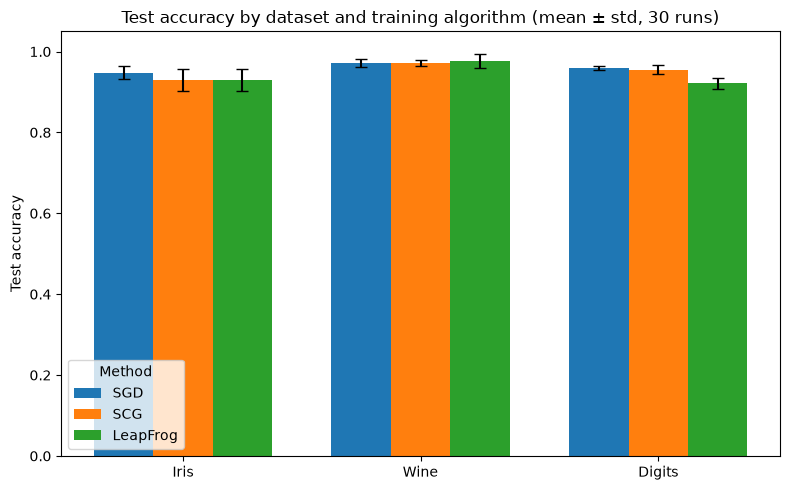

In [70]:
datasets_c = ["Iris", "Wine", "Digits"]
methods_c = ["SGD", "SCG", "LeapFrog"]
x = np.arange(len(datasets_c))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, method in enumerate(methods_c):
    means = [classification_master_table.loc[
                (classification_master_table["Dataset"] == d) & (classification_master_table["Method"] == method),
                "Accuracy (mean)"].values[0] for d in datasets_c]
    stds = [classification_master_table.loc[
                (classification_master_table["Dataset"] == d) & (classification_master_table["Method"] == method),
                "Accuracy (std)"].values[0] for d in datasets_c]
    ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=4, label=method)

ax.set_xticks(x)
ax.set_xticklabels(datasets_c)
ax.set_ylabel("Test accuracy")
ax.set_title("Test accuracy by dataset and training algorithm (mean ± std, 30 runs)")
ax.set_ylim(0, 1.05)
ax.legend(title="Method")
plt.tight_layout()
plt.show()

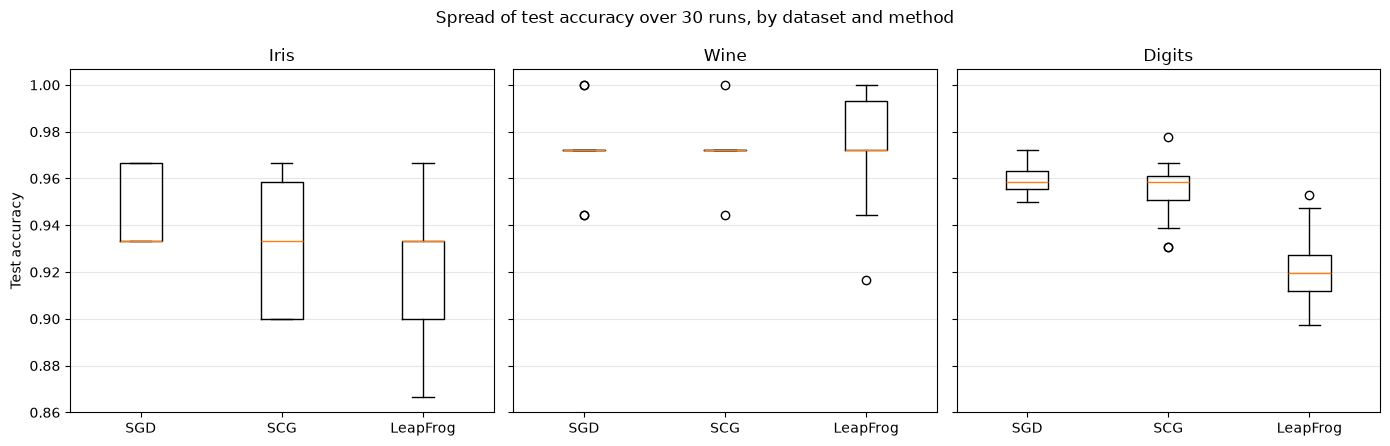

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

classification_run_lists = {
    "Iris":    {"SGD": pd.DataFrame(final_model_rows), "SCG": final_scg, "LeapFrog": final_lf},
    "Wine":    {"SGD": final_wine_sgd, "SCG": final_wine_scg, "LeapFrog": final_wine_lf},
    "Digits":  {"SGD": final_digits_sgd, "SCG": final_digits_scg, "LeapFrog": final_digits_lf},
}

for ax, dataset in zip(axes, datasets_c):
    data = [classification_run_lists[dataset][m]["accuracy"].values for m in methods_c]
    ax.boxplot(data, tick_labels=methods_c)
    ax.set_title(dataset)
    ax.set_ylabel("Test accuracy" if dataset == "Iris" else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Spread of test accuracy over 30 runs, by dataset and method")
plt.tight_layout()
plt.show()

## Now lets do it for the approximation functions

In [ ]:
regression_runs = {
    ("Low", "SGD"): final_lc_sgd, ("Low", "SCG"): final_lc_scg, ("Low", "LeapFrog"): final_lc_lf,
    ("Medium", "SGD"): final_mc_sgd, ("Medium", "SCG"): final_mc_scg, ("Medium", "LeapFrog"): final_mc_lf,
    ("High", "SGD"): final_hc_sgd, ("High", "SCG"): final_hc_scg, ("High", "LeapFrog"): final_hc_lf,
}

regression_rows = []
for (dataset, method), df in regression_runs.items():
    m, s = df.mean(), df.std()
    regression_rows.append({
        "Complexity": dataset,
        "Method": method,
        "RMSE (mean)": m["test_rmse"], "RMSE (std)": s["test_rmse"],
        "MSE (mean)": m["test_mse"], "SSE (mean)": m["test_sse"],
        "R2 (mean)": m["test_r2"], "R2 (std)": s["test_r2"],
    })

regression_master_table = pd.DataFrame(regression_rows).round(5)
regression_master_table = regression_master_table.sort_values(["Complexity", "Method"]).reset_index(drop=True)
regression_master_table

In [ ]:
datasets_r = ["Low", "Medium", "High"]
methods_r = ["SGD", "SCG", "LeapFrog"]
x = np.arange(len(datasets_r))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, method in enumerate(methods_r):
    rmse_means = [regression_master_table.loc[
                    (regression_master_table["Complexity"] == d) & (regression_master_table["Method"] == method),
                    "RMSE (mean)"].values[0] for d in datasets_r]
    rmse_stds = [regression_master_table.loc[
                    (regression_master_table["Complexity"] == d) & (regression_master_table["Method"] == method),
                    "RMSE (std)"].values[0] for d in datasets_r]
    axes[0].bar(x + (i - 1) * width, rmse_means, width, yerr=rmse_stds, capsize=4, label=method)

    r2_means = [regression_master_table.loc[
                    (regression_master_table["Complexity"] == d) & (regression_master_table["Method"] == method),
                    "R2 (mean)"].values[0] for d in datasets_r]
    r2_stds = [regression_master_table.loc[
                    (regression_master_table["Complexity"] == d) & (regression_master_table["Method"] == method),
                    "R2 (std)"].values[0] for d in datasets_r]
    axes[1].bar(x + (i - 1) * width, r2_means, width, yerr=r2_stds, capsize=4, label=method)

axes[0].set_xticks(x); axes[0].set_xticklabels(datasets_r)
axes[0].set_ylabel("Test RMSE"); axes[0].set_title("Test RMSE by complexity level")
axes[0].legend(title="Method")

axes[1].set_xticks(x); axes[1].set_xticklabels(datasets_r)
axes[1].set_ylabel("Test $R^2$"); axes[1].set_title("Test $R^2$ by complexity level")
axes[1].legend(title="Method")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

regression_run_lists = {
    "Low":    {"SGD": final_lc_sgd, "SCG": final_lc_scg, "LeapFrog": final_lc_lf},
    "Medium": {"SGD": final_mc_sgd, "SCG": final_mc_scg, "LeapFrog": final_mc_lf},
    "High":   {"SGD": final_hc_sgd, "SCG": final_hc_scg, "LeapFrog": final_hc_lf},
}

for ax, dataset in zip(axes, datasets_r):
    data = [regression_run_lists[dataset][m]["test_rmse"].values for m in methods_r]
    ax.boxplot(data, tick_labels=methods_r)
    ax.set_title(f"{dataset} complexity")
    ax.set_ylabel("Test RMSE" if dataset == "Low" else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Spread of test RMSE over 30 runs, by complexity level and method")
plt.tight_layout()
plt.show()

## 3. Lets mabye do what we did in assignment 1 and do a wilcoxnon test to determine the best model for the job per problem

In [ ]:
from scipy.stats import wilcoxon

print("Classification (metric = accuracy):")
for dataset in datasets_c:
    accs = {m: classification_run_lists[dataset][m]["accuracy"].values for m in methods_c}
    for m1, m2 in [("SGD", "SCG"), ("SGD", "LeapFrog"), ("SCG", "LeapFrog")]:
        stat, p = wilcoxon(accs[m1], accs[m2])
        print(f"  {dataset:8s} {m1} vs {m2:9s}: p = {p:.4f}")

print()
print("Regression (metric = RMSE):")
for dataset in datasets_r:
    rmses = {m: regression_run_lists[dataset][m]["test_rmse"].values for m in methods_r}
    for m1, m2 in [("SGD", "SCG"), ("SGD", "LeapFrog"), ("SCG", "LeapFrog")]:
        stat, p = wilcoxon(rmses[m1], rmses[m2])
        print(f"  {dataset:8s} {m1} vs {m2:9s}: p = {p:.4f}")